In [1]:
#import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

In [2]:
!pip install yfinance

Your Stock Analyser


Enter the stock symbol (Add .NS in case of Indian Stock or Q to Quit):  MSFT



-----------------------------
Company Name: Microsoft Corporation
Current Price: 411.22 USD
Change: +18.21 (+4.63%)
-----------------------------



[*********************100%***********************]  1 of 1 completed


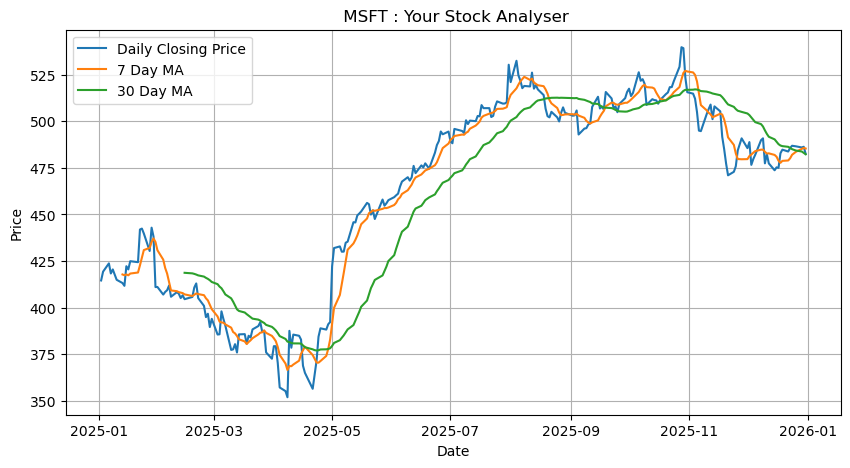

In [ ]:
import yfinance as yf

print("Your Stock Analyser")

while True:
    symbol = input("Enter the stock symbol (Add .NS in case of Indian Stock or Q to Quit): ").upper()

    if symbol == "Q":
        print("We End Here. See you again !!")
        break

    try:
        stock = yf.Ticker(symbol)
        info = stock.info

        name = info.get("longName", "N/A")
        price = info.get("currentPrice")
        prev_price = info.get("previousClose")
        currency = info.get("currency")

        if currency is None:
            if symbol.endswith(".NS"):
                currency = "INR"
            else:
                currency = "USD"

        print("\n-----------------------------")
        print(f"Company Name: {name}")
        print(f"Current Price: {price} {currency}")

        if price and prev_price:
            change = price - prev_price
            percent = (change / prev_price) * 100
            print(f"Change: {change:+.2f} ({percent:+.2f}%)")

        print("-----------------------------\n")


        df = yf.download(symbol, start = "2025-01-01", end = "2026-01-01", interval="1d")

        df["7_day_MA"] = df["Close"].rolling(window=7).mean()
        df["30_day_MA"] = df["Close"].rolling(window=30).mean()

        #Graph plotting

        plt.figure(figsize=(10,5))
        plt.plot (df["Close"],label ="Daily Closing Price")
        plt.plot(df["7_day_MA"],label = "7 Day MA")
        plt.plot(df["30_day_MA"],label = "30 Day MA")
        plt.title(f" {symbol} : Your Stock Analyser")
        plt.xlabel("Date")
        plt.ylabel("Price")
        plt.legend()
        plt.grid(True)
        plt.show()
        
        
        
    except Exception as e:
        print("Invalid symbol or Network error\n")